In [ ]:
!pip install tensorflowjs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.5/15.5 MB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 44.7 MB/s eta 0:00:00
  Attempting uninstall: packaging
    Found existing installation: packaging 24.1
    Uninstalling packaging-24.1:
      Successfully uninstalled packaging-24.1


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
# import tensorflowjs as tfjs
from tensorflow import keras

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
print(keras.__version__)
print(tf.__version__)

3.4.1
2.17.0


In [ ]:
!tensorflowjs_converter --input_format keras \
/content/drive/MyDrive/classify/project.h5 \
/content/drive/MyDrive/classify/

2024-06-07 05:30:24.738877: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [ ]:
model = keras.models.load_model("/content/drive/MyDrive/classify/edit_model.keras")
print(model.name_scope)
#tfjs.converters.save_keras_model(model, "/content/drive/MyDrive/classify/edit_model.keras.zip")

AttributeError: 'Functional' object has no attribute 'name_scope'

In [ ]:
model

In [ ]:
from tensorflow.keras.models import load_model

# โหลดโมเดลจากไฟล์ HDF5
loaded_model = load_model("/content/drive/MyDrive/classify/edit_model.keras")


In [ ]:
cd/content/drive/MyDrive/classify/

/content/drive/MyDrive/classify


In [ ]:
PATH = '/content/drive/MyDrive/classify/'
test = '/content/drive/MyDrive/test/'

In [ ]:
file_names = os.listdir(test)
print(file_names)

['holybasil', 'lime', 'kaffir lime leaves', 'turmeric(ขมิ้น)', 'Bitter cucumber(มะระขี้นก)', 'celery(ตั้งโอ๋)', 'chives leaves(ใบกุ๋ยช่าย)', 'coriander(ผักชี)', 'finger root(กระชาย)', 'ginger(ขิง)', 'Mango yawns, lemon ho', 'spring onion(ต้นหอม)', ' cassia leaves(ใบขี้เหล็ก)', 'galangal(ข่า)', 'pandan leaf(ใบเตย)', 'basil(โหระพา)', 'climbing wattle(ชะอม)', 'lemon grass(ตะไคร้)', 'gourd(ตำลึง)', 'wild betel(ใบพลู)']


In [ ]:
train_dir = os.path.join(PATH)
validation_dir = os.path.join(test)

### กำหนดขนาดรูป

In [ ]:
BATCH_SIZE = 32
IMG_SIZE = (180, 180)

In [ ]:
train_dataset = tf.keras.utils.image_dataset_from_directory(train_dir,
                                                            shuffle=True,
                                                            batch_size=BATCH_SIZE,
                                                            image_size=IMG_SIZE,
                                                            validation_split=0.2,
                                                            subset="training",
                                                            seed=1234567,
                                                            label_mode="categorical")

validation_dataset = tf.keras.utils.image_dataset_from_directory(train_dir,
                                                            shuffle=True,
                                                            batch_size=BATCH_SIZE,
                                                            image_size=IMG_SIZE,
                                                            validation_split=0.2,
                                                            subset="validation",
                                                            seed=1234567,
                                                            label_mode="categorical")

Found 2499 files belonging to 20 classes.
Using 2000 files for training.
Found 2499 files belonging to 20 classes.
Using 499 files for validation.


In [ ]:
test_dataset = tf.keras.utils.image_dataset_from_directory( validation_dir,
                                                                 shuffle=False,
                                                                 batch_size=BATCH_SIZE,
                                                                 image_size=IMG_SIZE,
                                                                  label_mode="categorical")

Found 2000 files belonging to 20 classes.


In [ ]:
from PIL import Image
images = []
for filename in os.listdir(test):
    if filename.endswith(('.bmp', '.gif', '.jpeg', '.jpg', '.png')):  # กรองเฉพาะไฟล์ภาพ
        img_path = os.path.join(test, filename)
        img = Image.open(img_path)
        images.append(img)

In [ ]:
validation_dataset.class_names

[' cassia leaves(ใบขี้เหล็ก)',
 'Bitter cucumber(มะระขี้นก)',
 'Mango yawns, lemon ho',
 'basil(โหระพา)',
 'celery(ตั้งโอ๋)',
 'chives leaves(ใบกุ๋ยช่าย)',
 'climbing wattle(ชะอม)',
 'coriander(ผักชี)',
 'finger root(กระชาย)',
 'galangal(ข่า)',
 'ginger(ขิง)',
 'gourd(ตำลึง)',
 'holybasil',
 'kaffir lime leaves',
 'lemon grass(ตะไคร้)',
 'lime',
 'pandan leaf(ใบเตย)',
 'spring onion(ต้นหอม)',
 'turmeric(ขมิ้น)',
 'wild betel(ใบพลู)']

In [ ]:
# class_names = train_dataset.class_names
# plt.figure(figsize=(10, 10))
# for images, labels in train_dataset.take(1):
#   for i in range(9):
#     ax = plt.subplot(3, 3, i + 1)
#     plt.imshow(images[i].numpy().astype("uint8"))
#     plt.title(class_names[labels[i]])
#     plt.axis("off")

In [ ]:
val_batches = tf.data.experimental.cardinality(validation_dataset)
test_dataset = validation_dataset.take(val_batches // 5)
validation_dataset = validation_dataset.skip(val_batches // 5)

In [ ]:
print('Number of validation batches: %d' % tf.data.experimental.cardinality(validation_dataset))
print('Number of test batches: %d' % tf.data.experimental.cardinality(test_dataset))

Number of validation batches: 14
Number of test batches: 3


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

### Data augment

In [ ]:
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip('horizontal'),
  tf.keras.layers.RandomRotation(0.2),
  #tf.keras.layers.RandomSaturation(3),
  # tf.keras.layers.RandomCrop(central_fraction=0.5),
])

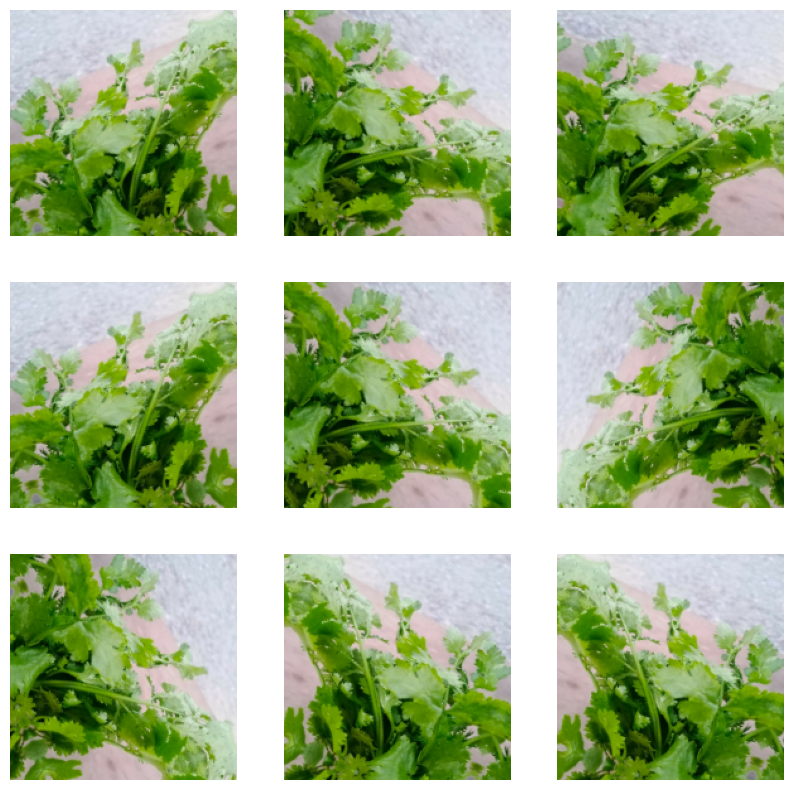

In [ ]:
for image, _ in train_dataset.take(1):
  plt.figure(figsize=(10, 10))
  first_image = image[0]
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    augmented_image = data_augmentation(tf.expand_dims(first_image, 0))
    plt.imshow(augmented_image[0] / 255)
    plt.axis('off')

In [ ]:

# for image, _ in train_dataset.take(1):
#     plt.figure(figsize=(10, 10))
#     first_image = image[0]
#     for i in range(3):
#         seed = (i,0)  # กำหนด seed ให้มีขนาดเป็น (2,)
#         stateless_random_crop = tf.image.stateless_random_crop(image, size=[210, 300, 3], seed=seed)
#         visualize(first_image, stateless_random_crop[0])

In [ ]:
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

In [ ]:
rescale = tf.keras.layers.Rescaling(1./127.5, offset=-1)

In [ ]:
# Create the base model from the pre-trained model MobileNet V2
IMG_SHAPE = IMG_SIZE + (3,)
base_model = tf.keras.applications.MobileNetV2(input_shape=IMG_SHAPE,
                                               include_top=False,                                               weights='imagenet')

9406464/9406464 [==============================] - 0s 0us/step


In [ ]:
image_batch, label_batch = next(iter(train_dataset))
feature_batch = base_model(image_batch)
print(feature_batch.shape)

(32, 6, 6, 1280)


In [ ]:
base_model.trainable = False

In [ ]:
# Let's take a look at the base model architecture
base_model.summary()

Model: "mobilenetv2_1.00_224"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 180, 180, 3)]        0         []                            
                                                                                                  
 Conv1 (Conv2D)              (None, 90, 90, 32)           864       ['input_1[0][0]']             
                                                                                                  
 bn_Conv1 (BatchNormalizati  (None, 90, 90, 32)           128       ['Conv1[0][0]']               
 on)                                                                                              
                                                                                                  
 Conv1_relu (ReLU)           (None, 90, 90, 32)           0         ['bn_Conv1[

In [ ]:
global_average_layer = tf.keras.layers.GlobalAveragePooling2D()
feature_batch_average = global_average_layer(feature_batch)
print(feature_batch_average.shape)

(32, 1280)


In [ ]:
prediction_layer = tf.keras.layers.Dense(20, activation="softmax")
prediction_batch = prediction_layer(feature_batch_average)
print(prediction_batch.shape)

(32, 20)


In [ ]:
inputs = tf.keras.Input(shape=(180, 180, 3))
x1 = data_augmentation(inputs)
x2 = preprocess_input(x1)
x3 = base_model(x2, training=False)
x4 = global_average_layer(x3)
x5 = tf.keras.layers.Dropout(0.2)(x4)
outputs = prediction_layer(x5)
model = tf.keras.Model(inputs, outputs)

In [ ]:
base_learning_rate = 0.0001
# model.compile(optimizer='your_optimizer', loss='binary_crossentropy', metrics=['accuracy'])
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=base_learning_rate),
              loss=tf.keras.losses.CategoricalCrossentropy(),
              metrics=['accuracy'])

In [ ]:
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 180, 180, 3)]     0         
                                                                 
 sequential_2 (Sequential)   (None, 180, 180, 3)       0         
                                                                 
 tf.math.truediv (TFOpLambd  (None, 180, 180, 3)       0         
 a)                                                              
                                                                 
 tf.math.subtract (TFOpLamb  (None, 180, 180, 3)       0         
 da)                                                             
                                                                 
 mobilenetv2_1.00_224 (Func  (None, 6, 6, 1280)        2257984   
 tional)                                                         
                                                             

In [ ]:
initial_epochs = 20
loss0, accuracy0 = model.evaluate(validation_dataset)

14/14 [==============================] - 123s 3s/step - loss: 3.7025 - accuracy: 0.0167


In [ ]:
print("initial loss: {:.2f}".format(loss0))
print("initial accuracy: {:.2f}".format(accuracy0))

initial loss: 3.70
initial accuracy: 0.02


In [ ]:
history = model.fit(train_dataset,
                    epochs=initial_epochs,
                    validation_data=validation_dataset)

Epoch 1/20
65/65 [==============================] - 443s 7s/step - loss: 3.1968 - accuracy: 0.0883 - val_loss: 2.5413 - val_accuracy: 0.2339
Epoch 2/20
65/65 [==============================] - 177s 3s/step - loss: 2.3886 - accuracy: 0.2840 - val_loss: 1.9464 - val_accuracy: 0.4153
Epoch 3/20
65/65 [==============================] - 175s 3s/step - loss: 1.8928 - accuracy: 0.4316 - val_loss: 1.5284 - val_accuracy: 0.5919
Epoch 4/20
65/65 [==============================] - 184s 3s/step - loss: 1.5157 - accuracy: 0.5704 - val_loss: 1.2785 - val_accuracy: 0.6659
Epoch 5/20
65/65 [==============================] - 171s 2s/step - loss: 1.2830 - accuracy: 0.6369 - val_loss: 1.1111 - val_accuracy: 0.6945
Epoch 6/20
65/65 [==============================] - 184s 3s/step - loss: 1.1099 - accuracy: 0.6854 - val_loss: 0.9462 - val_accuracy: 0.7518
Epoch 7/20
65/65 [==============================] - 180s 3s/step - loss: 0.9902 - accuracy: 0.7150 - val_loss: 0.8093 - val_accuracy: 0.8043
Epoch 8/20
65

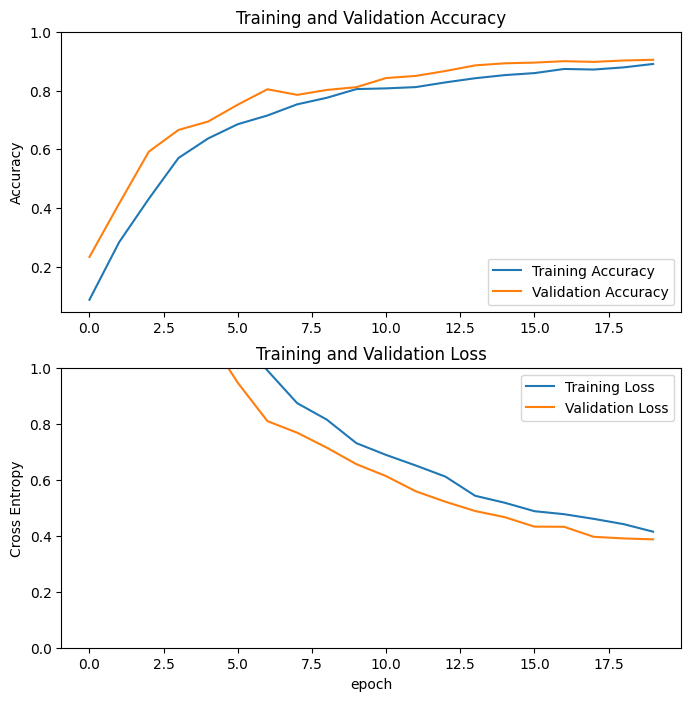

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0,1.0])
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

#Save model

In [ ]:
predicted_classes = np.array([])
true_classes =  np.array([])

for x, y in validation_dataset:
  predicted_classes = np.concatenate([predicted_classes, np.argmax(model.predict(x), axis = -1)])
  true_classes      = np.concatenate([true_classes     , np.argmax(y.numpy(), axis = -1)])

NameError: name 'model' is not defined

## Confusion matrix

In [ ]:
confusion_matrix(true_classes, predicted_classes)

<tf.Tensor: shape=(20, 20), dtype=int32, numpy=
array([[74,  0,  0,  6,  7,  0,  3,  3,  0,  0,  0,  1,  3,  0,  0,  0,
         2,  0,  0,  0],
       [ 0, 68,  3,  2,  2,  0,  3,  0,  0,  0,  0,  3, 20,  0,  0,  1,
         0,  1,  0,  3],
       [ 0,  0, 99,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  4,
         0,  0,  1,  0],
       [ 1,  3, 12, 49, 14,  0,  1,  3,  0,  0,  0,  0, 16,  0,  1,  0,
         0,  0,  0,  0],
       [ 1,  0,  0,  0, 45,  1,  0, 42,  0,  3,  0,  0,  5,  0,  0,  0,
         0,  1,  0,  0],
       [ 2,  1,  0,  0,  2, 48,  3, 15,  0,  2,  0,  0,  0,  0, 10,  0,
         0, 18,  0,  0],
       [20,  3,  0,  2,  3,  1, 14, 35,  0,  2,  0,  0,  5,  0,  5,  0,
         0, 16,  0,  0],
       [ 1,  1,  1,  3, 33,  0,  0, 35,  0,  0,  0,  0, 25,  0,  0,  0,
         0,  1,  0,  0],
       [ 0,  0,  1,  0,  1,  3,  0,  0, 73, 12,  4,  0,  0,  0,  6,  0,
         0,  1,  5,  0],
       [ 0,  0,  0,  0,  2,  0,  0,  0,  4, 80,  8,  0,  0,  0,  3,  0,
       

In [ ]:
from tensorflow.math import argmax
actual_y = [ x for x in test_dataset ]
print(actual_y)

[<tf.Tensor: shape=(30, 180, 180, 3), dtype=float32, numpy=
array([[[[5.30000000e+01, 5.90000000e+01, 5.70000000e+01],
         [5.70000000e+01, 6.60000000e+01, 6.50000000e+01],
         [3.40000000e+01, 4.20000000e+01, 4.40000000e+01],
         ...,
         [7.50000000e+01, 8.90000000e+01, 8.90000000e+01],
         [6.90000000e+01, 8.10000000e+01, 8.10000000e+01],
         [6.70000000e+01, 7.90000000e+01, 7.90000000e+01]],

        [[3.90000000e+01, 4.50000000e+01, 4.50000000e+01],
         [4.90000000e+01, 5.80000000e+01, 5.70000000e+01],
         [5.80000000e+01, 6.60000000e+01, 6.80000000e+01],
         ...,
         [7.50000000e+01, 8.70000000e+01, 8.70000000e+01],
         [7.30000000e+01, 8.50000000e+01, 8.50000000e+01],
         [9.20000000e+01, 1.04000000e+02, 1.04000000e+02]],

        [[4.90000000e+01, 5.80000000e+01, 5.70000000e+01],
         [4.00000000e+01, 4.60000000e+01, 4.60000000e+01],
         [5.30000000e+01, 5.70000000e+01, 5.80000000e+01],
         ...,
         

In [ ]:
from tensorflow.math import argmax
actual_y = [ x for x in test_dataset ]
argmax_actual_y = argmax(actual_y, axis=1)
print(argmax_actual_y)

InvalidArgumentError: {{function_node __wrapped__Pack_N_2_device_/job:localhost/replica:0/task:0/device:CPU:0}} Shapes of all inputs must match: values[0].shape = [32,180,180,3] != values[1].shape = [32,20] [Op:Pack] name: 0

In [ ]:
for data in test_dataset.take(1):  # ดูข้อมูลตัวอย่างแค่ 1 ตัวอย่าง
    print(data)


tf.Tensor(
[[[[108.166664  165.16667    94.166664 ]
   [104.166664  161.16667    90.166664 ]
   [101.666664  158.66667    87.666664 ]
   ...
   [161.5       206.16667   123.333336 ]
   [142.        194.5       122.66667  ]
   [114.        156.         90.       ]]

  [[111.5       168.5        97.5      ]
   [107.5       164.5        93.5      ]
   [109.5       166.5        95.5      ]
   ...
   [125.5       167.5        88.5      ]
   [ 95.        130.         67.5      ]
   [ 73.        113.         47.5      ]]

  [[110.66667   167.66667    96.66667  ]
   [102.333336  159.33334    88.333336 ]
   [108.5       165.5        94.5      ]
   ...
   [140.66666   178.66666   105.33333  ]
   [117.        135.33333    84.833336 ]
   [120.99999   156.16666    92.166664 ]]

  ...

  [[ 51.166626  111.833374   17.333252 ]
   [ 63.499634  120.83313    33.999756 ]
   [ 59.66626   111.833374   34.83313  ]
   ...
   [103.833374   77.000244   58.000732 ]
   [ 74.16687    49.83362    37.33374  ]
   [ 

In [ ]:
#อันเดิม
from tensorflow.math import argmax
actual_y = [ k for x,y in test_dataset for k in y]
argmax_actual_y = argmax(actual_y, axis=1)
print(argmax_actual_y)

tf.Tensor([ 0  0  0 ... 19 19 19], shape=(2000,), dtype=int64)


In [ ]:
#อันเดิม
# ทำการทำนายกับชุดข้อมูลทดสอบ
#y_pred = model.evaluate(validation_dataset)
y_pred = loaded_model.predict( test_dataset) ### จาก model ที่เซฟทิ้งไว้
print(y_pred)

63/63 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step
[[8.8445044e-01 2.8515630e-04 4.6813176e-03 ... 2.6413109e-03
  7.8878331e-04 2.6125423e-04]
 [6.1512190e-01 1.1154395e-02 4.5688372e-04 ... 6.5027564e-03
  4.6719131e-03 1.2733410e-04]
 [8.6359835e-01 1.0308891e-03 3.2879590e-04 ... 1.9239734e-03
  1.1265073e-03 2.1061857e-04]
 ...
 [1.5028857e-03 1.3093535e-02 7.0933434e-03 ... 2.5992052e-04
  2.7944797e-03 2.4282326e-01]
 [1.5233770e-03 2.6234735e-02 2.5099711e-02 ... 8.2336564e-04
  1.1594006e-03 2.4404173e-01]
 [4.2499504e-03 1.3424182e-02 1.4519743e-02 ... 1.9527087e-03
  3.7107123e-03 1.2241661e-03]]


In [ ]:
# resized_images = [tf.image.resize(x, (180, 180 )) for x in test_dataset]
# print(resized_images)

[<tf.Tensor: shape=(30, 180, 180, 3), dtype=float32, numpy=
array([[[[5.30000000e+01, 5.90000000e+01, 5.70000000e+01],
         [5.70000000e+01, 6.60000000e+01, 6.50000000e+01],
         [3.40000000e+01, 4.20000000e+01, 4.40000000e+01],
         ...,
         [7.50000000e+01, 8.90000000e+01, 8.90000000e+01],
         [6.90000000e+01, 8.10000000e+01, 8.10000000e+01],
         [6.70000000e+01, 7.90000000e+01, 7.90000000e+01]],

        [[3.90000000e+01, 4.50000000e+01, 4.50000000e+01],
         [4.90000000e+01, 5.80000000e+01, 5.70000000e+01],
         [5.80000000e+01, 6.60000000e+01, 6.80000000e+01],
         ...,
         [7.50000000e+01, 8.70000000e+01, 8.70000000e+01],
         [7.30000000e+01, 8.50000000e+01, 8.50000000e+01],
         [9.20000000e+01, 1.04000000e+02, 1.04000000e+02]],

        [[4.90000000e+01, 5.80000000e+01, 5.70000000e+01],
         [4.00000000e+01, 4.60000000e+01, 4.60000000e+01],
         [5.30000000e+01, 5.70000000e+01, 5.80000000e+01],
         ...,
         

In [ ]:
#อันเดิม
from tensorflow.math import argmax, confusion_matrix
argmax_prediction = argmax(y_pred, axis=1)
print(argmax_prediction)

tf.Tensor([ 0  0  0 ... 13 12  3], shape=(2000,), dtype=int64)


In [ ]:
print("จำนวนข้อมูลใน y_actual:", len(argmax_actual_y))
print("จำนวนข้อมูลใน argmax_prediction:", len(argmax_prediction))

จำนวนข้อมูลใน y_actual: 2000
จำนวนข้อมูลใน argmax_prediction: 2000


In [ ]:
confusion_matrix(argmax_actual_y, argmax_prediction)

<tf.Tensor: shape=(20, 20), dtype=int32, numpy=
array([[80,  1,  0,  4,  5,  0,  2,  5,  0,  0,  0,  0,  1,  2,  0,  0,
         0,  0,  0,  0],
       [ 1, 76,  4,  0,  0,  0,  6,  0,  0,  0,  0,  5,  3,  2,  0,  0,
         0,  0,  1,  2],
       [ 0,  0, 96,  0,  0,  0,  0,  0,  0,  1,  0,  0,  0,  0,  0,  2,
         0,  0,  1,  0],
       [ 1,  0, 15, 39,  9,  0,  0,  5,  0,  1,  0,  1, 24,  2,  0,  0,
         0,  0,  1,  2],
       [ 1,  0,  1,  0, 49,  0,  1, 40,  0,  0,  0,  0,  7,  0,  0,  0,
         0,  1,  0,  0],
       [ 3,  0,  0,  0,  3, 39,  0, 16,  0,  1,  0,  0,  0,  0,  8,  0,
         3, 27,  0,  0],
       [16,  7,  1,  9,  2,  1, 14, 30,  0,  0,  0,  1,  0,  0,  5,  1,
         1, 11,  1,  0],
       [ 0,  1,  0,  1, 36,  0,  1, 28,  0,  0,  0,  0, 32,  0,  0,  0,
         0,  1,  0,  0],
       [ 0,  0,  0,  0,  0,  4,  0,  0, 75,  8,  5,  0,  0,  0,  1,  0,
         0,  0,  7,  0],
       [ 0,  0,  0,  0,  1,  0,  0,  0,  5, 64,  9,  0,  0,  0,  0,  0,
       

In [ ]:
confusion = confusion_matrix(argmax_actual_y, argmax_prediction)

In [ ]:
import seaborn as sns

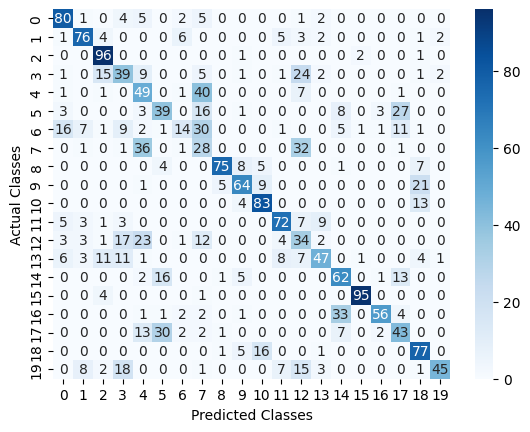

In [ ]:
confusion = confusion_matrix(argmax_actual_y, argmax_prediction)
sns.heatmap(confusion , cmap='Blues',  annot=True)
# plt.xticks(np.arange(20)+0.5, [' cassia leaves(ใบขี้เหล็ก)',
#  'Bitter cucumber(มะระขี้นก)',
#  'Mango yawns, lemon ho',
#  'basil(โหระพา)',
#  'celery(ตั้งโอ๋)',
#  'chives leaves(ใบกุ๋ยช่าย)',
#  'climbing wattle(ชะอม)',
#  'coriander(ผักชี)',
#  'finger root(กระชาย)',
#  'galangal(ข่า)',
#  'ginger(ขิง)',
#  'gourd(ตำลึง)',
#  'holybasil',
#  'kaffir lime leaves',
#  'lemon grass(ตะไคร้)',
#  'lime',
#  'pandan leaf(ใบเตย)',
#  'spring onion(ต้นหอม)',
#  'turmeric(ขมิ้น)',
#  'wild betel(ใบพลู)'])
# plt.yticks(np.arange(20)+0.5, [' cassia leaves(ใบขี้เหล็ก)',
#  'Bitter cucumber(มะระขี้นก)',
#  'Mango yawns, lemon ho',
#  'basil(โหระพา)',
#  'celery(ตั้งโอ๋)',
#  'chives leaves(ใบกุ๋ยช่าย)',
#  'climbing wattle(ชะอม)',
#  'coriander(ผักชี)',
#  'finger root(กระชาย)',
#  'galangal(ข่า)',
#  'ginger(ขิง)',
#  'gourd(ตำลึง)',
#  'holybasil',
#  'kaffir lime leaves',
#  'lemon grass(ตะไคร้)',
#  'lime',
#  'pandan leaf(ใบเตย)',
#  'spring onion(ต้นหอม)',
#  'turmeric(ขมิ้น)',
#  'wild betel(ใบพลู)'])
plt.xlabel("Predicted Classes")
plt.ylabel("Actual Classes")
plt.show()

Image 8 shape: (32, 180, 180, 3)
Number of dimensions: 4


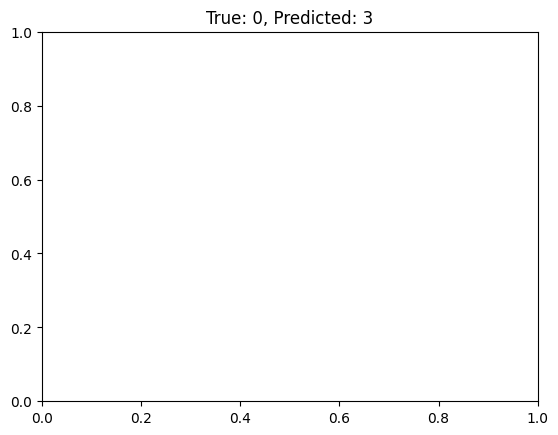

Image 9 shape: (32, 180, 180, 3)
Number of dimensions: 4


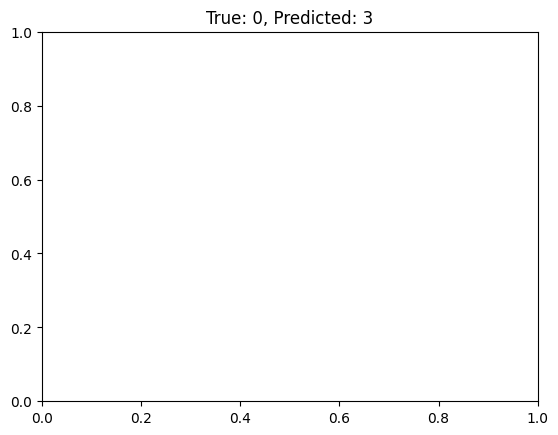

Image 16 shape: (32, 180, 180, 3)
Number of dimensions: 4


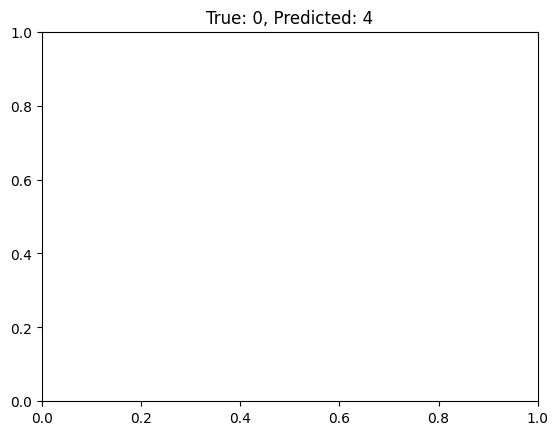

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ดึงข้อมูล images และ labels จาก test_dataset
images, _ = zip(*test_dataset)

# แสดงรายละเอียดของภาพที่ทำนายผิด
for i in incorrect_indices[:3]:  # แสดงแค่ 3 ภาพแรกที่ทำนายผิด
    image = images[i].numpy()  # ดึงภาพออกมาจาก dataset

    print(f"Image {i} shape: {image.shape}")
    print(f"Number of dimensions: {image.ndim}")

    # ตรวจสอบลักษณะของภาพ
    if image.ndim == 3:
        if image.shape[-1] == 1:
            image = np.squeeze(image, axis=-1)  # ถ้าเป็น grayscale
            plt.imshow(image, cmap='gray')
        elif image.shape[-1] == 3:
            plt.imshow(image)  # ถ้าเป็น RGB
        else:
            raise ValueError(f"Unexpected image channel dimension: {image.shape[-1]}")
    elif image.ndim == 2:
        plt.imshow(image, cmap='gray')  # ถ้าภาพมี 2 มิติ (grayscale)


    plt.title(f"True: {argmax_actual_y[i]}, Predicted: {argmax_prediction[i]}")
    plt.show()


In [ ]:
model.save("edit_model.keras")

In [ ]:
!pip install -q lib5c
!lib5c -v

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.2/16.2 MB 17.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 9.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 40.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
lib5c version 0.6.1


In [ ]:
!tensorflowjs_converter --input_format==keras /content/drive/MyDrive/classify/edit_model.keras /tmp/tfjs_model

2024-06-05 17:18:32.023139: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
usage: TensorFlow.js model converters. [-h]
                                       [--input_format {tfjs_layers_model,keras_saved_model,tf_hub,tf_frozen_model,keras,tf_saved_model,keras_keras}]
                                       [--output_format {tfjs_layers_model,keras_saved_model,keras,keras_keras,tfjs_graph_model}]
                                       [--signature_name SIGNATURE_NAME]
                                       [--saved_model_tags SAVED_MODEL_TAGS]
                                       [--quantize_float16 [QUANTIZE_FLOAT16]]
                                       [--quantize_uint8 [QUANTIZE_UINT8]]
                                       [--quantize_uint16 [QUANTIZE_UINT16]]
                                       [--quantization_bytes {1,2}] [--split_weights_by_layer]
                                       [--version] [--skip_op_check]
       

In [ ]:
os.listdir('tfjs_model')

FileNotFoundError: [Errno 2] No such file or directory: 'tfjs_model'

In [ ]:
tf.experimental.numpy.experimental_enable_numpy_behavior()

In [ ]:
if isinstance(argmax_actual_y, tf.Tensor):
    actual_y = argmax_actual_y.numpy()
if isinstance(argmax_prediction, tf.Tensor):
    predicted_y = argmax_prediction.numpy()

In [ ]:
actual_y = np.argmax(actual_y, axis=1)
predicted_y = np.argmax(predicted_y, axis=1)

AxisError: axis 1 is out of bounds for array of dimension 1

In [ ]:
cm = confusion_matrix(actual_y, predicted_y)

In [ ]:
# แปลง label_batch เป็นตัวเลข
label = np.argmax(label_batch, axis=1)

# ตัวอย่างการพิมพ์ผลลัพธ์หลังจากการแปลง
print(label)


In [ ]:
aomsin = [ (6,1), (4,2) , (3,3), (5,4) ,(6,5) ,(8,7), (0,8),(7,9)]

print([(b,a) for a,b in aomsin])

In [ ]:
model.save("project.h5")

In [ ]:
print(y_pred)

In [ ]:
print(y_test)

In [ ]:
# นับจำนวนข้อมูลใน y_test และ y_pred
num_samples_y_test = len(y_test)
num_samples_y_pred = len(y_pred)

# แสดงจำนวนข้อมูล
print("จำนวนข้อมูลใน y_test:", num_samples_y_test)
print("จำนวนข้อมูลใน y_pred:", num_samples_y_pred)


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)


In [ ]:
# ทำการทำนายกับชุดข้อมูลทดสอบ
# y_pred = model.predict(validation_dataset)
# y_test = accuracy0

# สร้าง Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# คำนวณ metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

## ทดสอบ

In [ ]:
# ตั้งค่าที่อยู่ของไฟล์รูปภาพที่ต้องการโหลด
image_fodername = 'มะกรูด1.jpg'
data_dir3 = '/content/drive/MyDrive/TestT/'  # ที่อยู่ของไฟล์รูปภาพ

# ต่อที่อยู่ของไฟล์รูปภาพเข้ากับชื่อไฟล์
img_path = os.path.join(data_dir3, image_fodername)

# โหลดรูปภาพ
new_img = tf.keras.utils.load_img(img_path, target_size=(180 ,180))

In [ ]:
img_array = tf.keras.utils.img_to_array(new_img)
img_array = tf.expand_dims(img_array, 0) # Create a batch

predictions = model.predict(img_array)
score = tf.nn.softmax(predictions[0])

print(
    "This image most likely belongs to {} with a {:.2f} percent confidence."
    .format(class_names[np.argmax(score)], 100 * np.max(score))
)